# AthleAgent — ML Journey (presentation)

**Live demo** on a small CSV slice. Same code as production (`train_model.py`).

| Step | What you will see |
|------|-------------------|
| 1 | Load synthetic data |
| 2 | Explore features & injury signals |
| 3 | Athlete holdout split |
| 4 | Train **all candidates** |
| 5 | **Our tiered selection algorithm** picks the winner |

`athlete_injury_data.csv` is **not in git** (too large). Part 1 generates it automatically on first run.

Full-scale deploy: `python ML_model/run_pipeline.py`.


## Part 0 — Target

Predict `injury_today` on day D. We optimize for **catching injuries** without flooding athletes with false alarms.


In [24]:
# pip install pandas numpy matplotlib jupyter ipykernel xgboost scikit-learn  (one-time)
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

def show_gates(df: pd.DataFrame, cols: list[str]) -> None:
    view = df.copy()
    for col in cols:
        if col in view.columns:
            view[col] = view[col].map({True: "PASS", False: "FAIL"})
    display(view)

_here = Path.cwd().resolve()
ML_ROOT = next(
    cand
    for cand in (
        _here / "ML_model",
        _here.parent / "ML_model",
        *(_here.parents[i] / "ML_model" for i in range(len(_here.parents))),
    )
    if (cand / "athlete_injury_data.csv").is_file()
)
PROJECT_ROOT = ML_ROOT.parent
sys.path.insert(0, str(ML_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "backend"))

import importlib

import train_model as _train_model  # noqa: E402
importlib.reload(_train_model)  # pick up latest train_model.py in long-lived kernels

from train_model import (  # noqa: E402
    LABEL_COLUMN,
    OPERATING_TIER_LABELS,
    THRESHOLD,
    add_selection_column,
    build_fixed_threshold_gate_table,
    build_operating_points_table,
    load_dataset,
    make_train_split,
    model_catalog,
    pick_best_model,
    policy_thresholds,
    subset_dataset,
    train_and_compare,
)
from services.model_features import MODEL_FEATURE_COLUMNS  # noqa: E402

LABEL_COL = LABEL_COLUMN
DATA_PATH = ML_ROOT / "fixtures" / "athlete_injury_demo.csv"
SEED = 42
SUBSET_ATHLETES = 50
SUBSET_DAYS = 120
HOLDOUT_RATIO = 0.2

train_result = None
split = None
df_demo = None
fixed_gates = None
operating_table = None
WINNER = None
OPERATING_THRESHOLD = None


ML root: C:\dev\final_project_AthleAgent\ML_model
Candidates (5): LogisticRegression, RandomForest, GradientBoosting, XGBoostCalibratedTuned, XGBoostDeep
Candidates to train: 5


## Part 1 — Load data (subset)

Uses **`fixtures/athlete_injury_demo.csv`** from git, then a smaller slice for fast training.


In [25]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Pull latest git or run: "
        "python ML_model/data_generator.py (full CSV, not required for this notebook)."
    )

df_raw = load_dataset(DATA_PATH)
df_demo = subset_dataset(df_raw, n_athletes=SUBSET_ATHLETES, max_days_per_athlete=SUBSET_DAYS, seed=SEED)

display(pd.Series({
    "source CSV": DATA_PATH.name,
    "full CSV rows": len(df_raw),
    "demo rows": len(df_demo),
    "demo athletes": df_demo["athlete_id"].nunique(),
    "injury-day rate": f"{df_demo[LABEL_COL].mean():.2%}",
}).to_frame("value"))
display(df_demo.head(5))


,value
full CSV rows,359000
demo rows,6000
demo athletes,50
injury-day rate,16.00%


,athlete_id,date,bmi,age,body_fat_pct,vo2_max,history_injury_count,injured_yesterday,daily_distance_km,workout_intensity_minutes,...,muscle_soreness,energy_level,injury_today,acute_load_7d,acwr_ratio,calorie_balance,sleep_debt_3d,hrv_drop,load_recovery_imbalance,speed_intensity_ratio
0,60,2025-01-07,20.02,34,21.9,53.0,1,0,2.28,13,...,7,8,0,6.050000,0.909357,775,1.8,-4.428571,1.636843,1.212787
1,60,2025-01-08,20.02,34,21.9,52.4,1,0,1.21,5,...,4,6,0,5.108571,0.853282,771,0.4,3.142857,0.341313,1.292922
2,60,2025-01-09,20.02,34,21.6,51.9,1,0,3.85,22,...,6,8,0,4.592857,0.835734,335,0.9,1.000000,0.752161,1.311978
3,60,2025-01-10,20.02,34,21.6,52.8,1,0,4.26,24,...,6,7,0,4.004286,0.829646,594,1.7,1.000000,1.410397,1.261673
4,60,2025-01-11,20.02,34,22.0,53.6,1,0,4.23,21,...,5,4,0,3.470000,0.836127,985,2.4,5.857143,2.006705,1.290546


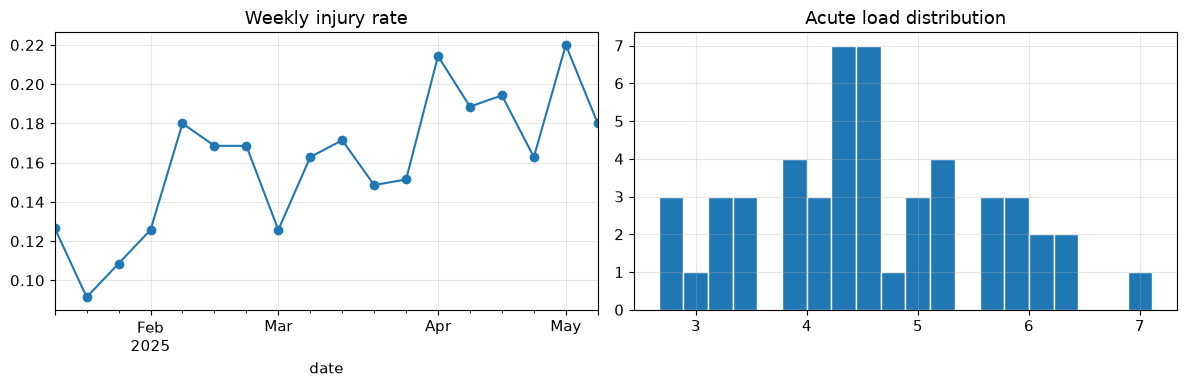

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_demo.groupby(df_demo["date"].dt.to_period("W"))[LABEL_COL].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Weekly injury rate")
df_demo.groupby("athlete_id")["acute_load_7d"].mean().hist(bins=20, ax=axes[1], edgecolor="white")
axes[1].set_title("Acute load distribution")
plt.tight_layout()
plt.show()


## Part 2 — Top correlations with injury


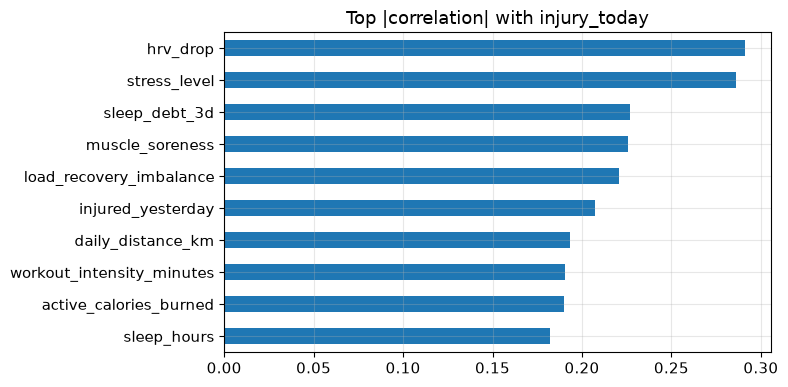

In [27]:
num_cols = df_demo.select_dtypes(include=[np.number]).columns
corr = df_demo[num_cols].corr()[LABEL_COL].drop(LABEL_COL).abs().sort_values(ascending=False).head(10)
corr.sort_values().plot(kind="barh", figsize=(8, 4), title="Top |correlation| with injury_today")
plt.tight_layout()
plt.show()


## Part 3 — Features

35 features in production contract. Rolling MA7 added before training.


In [28]:
print(f"Model contract: {len(MODEL_FEATURE_COLUMNS)} features")
print(", ".join(MODEL_FEATURE_COLUMNS[:8]), "...")


Model contract: 35 features
bmi, age, body_fat_pct, vo2_max, history_injury_count, injured_yesterday, daily_distance_km, workout_intensity_minutes ...


## Part 4 — Train / holdout split

**By athlete** (20% holdout) — no row-level leakage.


In [29]:
split = make_train_split(df_demo, holdout_ratio=HOLDOUT_RATIO, seed=SEED)
display(pd.DataFrame([
    ("train rows", len(split.y_train)),
    ("holdout rows", len(split.y_test)),
    ("train injury rate", f"{split.y_train.mean():.2%}"),
    ("holdout injury rate", f"{split.y_test.mean():.2%}"),
    ("features", len(split.feature_columns)),
], columns=["item", "value"]))


,item,value
0,train rows,4800
1,holdout rows,1200
2,train injury rate,16.31%
3,holdout injury rate,14.75%
4,features,35


## Part 5 — Model selection (our algorithm)

**Problem:** ROC-AUC alone is not enough for injury UX.
- We need **high recall** (catch real injuries)
- We cap **false-positive rate** (avoid alert fatigue)
- Precision/F1 matter once safety gates are met

**Solution:** tiered threshold search + ranked policy (`pick_best_model` in `train_model.py`).


### 5.1 — Graded policy gates

Every candidate is evaluated against these thresholds (production + backend gate).


In [30]:
gates = policy_thresholds()
display(pd.DataFrame([
    ("Recall hard minimum", gates["recall_hard_min"], "Must catch ≥80% of holdout injuries @ operating point"),
    ("FPR maximum @ operating", gates["fpr_max_operating"], "Limit false alarms"),
    ("Precision minimum", gates["precision_min"], "When all gates pass (Tier 0)"),
    ("F1 minimum", gates["f1_min"], "When all gates pass (Tier 0)"),
    ("Fixed comparison threshold", gates["fixed_comparison_threshold"], "Baseline table before sweep tuning"),
], columns=["Gate", "Value", "Why"]))


,Gate,Value,Why
0,Recall hard minimum,0.80,Must catch ≥80% of holdout injuries @ operatin...
1,FPR maximum @ operating,0.55,Limit false alarms
2,Precision minimum,0.13,When all gates pass (Tier 0)
3,F1 minimum,0.22,When all gates pass (Tier 0)
4,Fixed comparison threshold,0.18,Baseline table before sweep tuning


### 5.2 — Train all candidates (live)

Each model: fit on train → predict holdout → threshold sweep.


In [31]:
display(Markdown(f"**Training {len(model_catalog())} models…** (~1–3 min on demo subset)"))
train_result = train_and_compare(split, verbose=True)
WINNER = train_result.best_model_name
OPERATING_THRESHOLD = train_result.best_operating_threshold
print(f"\nTraining complete. Policy will pick among all {len(train_result.results_df)} models.")


**Training 5 models…** (~1–3 min on demo subset)


Data split diagnostics:
- total_rows: 6000
- train_rows: 4800
- test_rows: 1200
- injury_rate_overall: 0.1600
- injury_rate_train:   0.1631
- injury_rate_test:    0.1475
Training LogisticRegression...
Training RandomForest...
Training GradientBoosting...
Training XGBoostCalibratedTuned...
Training XGBoostDeep...

Training complete. Policy will pick among all 5 models.


### 5.3 — Baseline @ fixed threshold 0.18

Before our algorithm: who **fails** the graded gates at a single threshold?

This shows why a simple "pick highest ROC-AUC" or fixed cutoff is not enough.


In [32]:
fixed_gates = build_fixed_threshold_gate_table(train_result.results_df)
n_pass = int(fixed_gates["pass_all_gates"].sum())
n_fail = len(fixed_gates) - n_pass
display(Markdown(f"**{n_pass} / {len(fixed_gates)}** models pass all gates @ threshold {THRESHOLD:.2f}"))
if n_fail:
    display(Markdown(f"**{n_fail} models fail** — see `failed_gates` column"))

show_gates(fixed_gates[[
    "Model", "Recall", "Precision", "F1", "FPR", "ROC-AUC",
    "pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates", "failed_gates",
]], ["pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates"])


**1 / 5** models pass all gates @ threshold 0.18

**4 models fail** — see `failed_gates` column

,Model,Recall,Precision,F1,FPR,ROC-AUC,pass_recall_hard,pass_fpr,pass_precision,pass_f1,pass_all_gates,failed_gates
0,RandomForest,0.870056,0.263699,0.404731,0.420332,0.824246,PASS,PASS,PASS,PASS,PASS,—
1,GradientBoosting,0.649718,0.396552,0.492505,0.171065,0.836876,FAIL,PASS,PASS,PASS,FAIL,recall_hard
2,XGBoostCalibratedTuned,0.621469,0.392857,0.481400,0.166178,0.829614,FAIL,PASS,PASS,PASS,FAIL,recall_hard
3,XGBoostDeep,0.711864,0.336898,0.457350,0.242424,0.820004,FAIL,PASS,PASS,PASS,FAIL,recall_hard
4,LogisticRegression,0.966102,0.183871,0.308943,0.741935,0.812405,PASS,FAIL,PASS,PASS,FAIL,fpr


### 5.4 — Threshold sweep

For each model we scan many thresholds and record Recall / Precision / F1 / FPR.


Sweep grid: **32** thresholds × **5** models = **160** rows

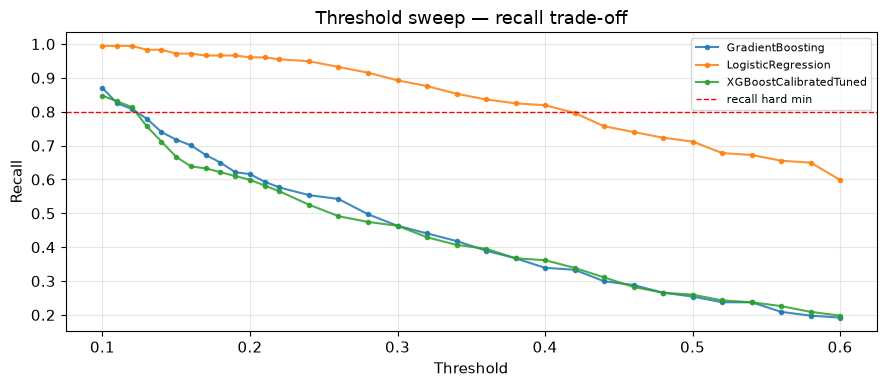

In [33]:
sweep_df = pd.DataFrame(train_result.threshold_rows)
display(Markdown(f"Sweep grid: **{sweep_df['Threshold'].nunique()}** thresholds × **{sweep_df['Model'].nunique()}** models = **{len(sweep_df)}** rows"))

# Recall vs threshold for 3 diverse models
sample_models = train_result.results_df.nlargest(1, "ROC-AUC")["Model"].tolist()
sample_models += train_result.results_df.nsmallest(1, "ROC-AUC")["Model"].tolist()
if WINNER not in sample_models:
    sample_models.append(WINNER)
sample_models = list(dict.fromkeys(sample_models))[:3]

fig, ax = plt.subplots(figsize=(9, 4))
for name in sample_models:
    sub = sweep_df[sweep_df["Model"] == name]
    ax.plot(sub["Threshold"], sub["Recall"], marker=".", label=name, alpha=0.85)
ax.axhline(policy_thresholds()["recall_hard_min"], color="red", ls="--", lw=1, label="recall hard min")
ax.set_xlabel("Threshold")
ax.set_ylabel("Recall")
ax.set_title("Threshold sweep — recall trade-off")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.5 — Our tiered algorithm (step by step)

For **each candidate**, pick one **operating point**:

| Tier | Rule | Meaning |
|------|------|---------|
| **0** | Recall ≥ hard min **and** FPR ≤ max **and** Precision ≥ min **and** F1 ≥ min | All gates pass — pick best F1 |
| **1** | Recall ≥ hard min **and** FPR ≤ max | Precision/F1 relaxed |
| **2** | Recall ≥ hard min only | FPR relaxed |
| **3** | Fallback | Best F1 among remaining thresholds |

Then **rank all models**: Tier (lower is better) → F1 → Precision → FPR → Recall → ROC-AUC → Brier.

```mermaid
flowchart TD
  A[All candidates] --> B[Threshold sweep each model]
  B --> C{Tier 0 all gates?}
  C -->|yes| T0[Best F1 in Tier 0]
  C -->|no| D{Tier 1 recall+FPR?}
  D -->|yes| T1[Best F1 in Tier 1]
  D -->|no| E{Tier 2 recall?}
  E -->|yes| T2[Best F1 in Tier 2]
  E -->|no| T3[Tier 3 fallback]
  T0 --> R[Rank: Tier then F1 Precision FPR Recall AUC Brier]
  T1 --> R
  T2 --> R
  T3 --> R
  R --> W[Winner = rank 1]
```


In [34]:
operating_table = build_operating_points_table(
    train_result.results_df,
    train_result.threshold_rows,
)
operating_table = add_selection_column(operating_table, WINNER)

tier_counts = (
    operating_table.groupby(["Tier", "Tier meaning"], as_index=False)
    .size()
    .rename(columns={"size": "models"})
)
display(Markdown("#### Models per tier"))
display(tier_counts)

display(Markdown("#### Full ranking after tiered operating-point search"))
show_gates(operating_table[[
    "Rank", "Model", "Selected", "Tier", "Threshold",
    "Recall", "Precision", "F1", "FPR", "ROC-AUC", "BrierScore",
    "pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates", "failed_gates",
]], ["pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates"])


#### Models per tier

,Tier,Tier meaning,models
0,0,All gates pass,5


#### Full ranking after tiered operating-point search

,Rank,Model,Selected,Tier,Threshold,Recall,Precision,F1,FPR,ROC-AUC,BrierScore,pass_recall_hard,pass_fpr,pass_precision,pass_f1,pass_all_gates,failed_gates
0,1,XGBoostCalibratedTuned,True,0,0.12,0.813559,0.312364,0.451411,0.309873,0.829614,0.095430,PASS,PASS,PASS,PASS,PASS,—
1,2,GradientBoosting,False,0,0.12,0.807910,0.308855,0.446875,0.312805,0.836876,0.094050,PASS,PASS,PASS,PASS,PASS,—
2,3,RandomForest,False,0,0.21,0.807910,0.294239,0.431373,0.335288,0.824246,0.103093,PASS,PASS,PASS,PASS,PASS,—
3,4,LogisticRegression,False,0,0.40,0.819209,0.287129,0.425220,0.351906,0.812405,0.169375,PASS,PASS,PASS,PASS,PASS,—
4,5,XGBoostDeep,False,0,0.12,0.807910,0.277670,0.413295,0.363636,0.820004,0.099555,PASS,PASS,PASS,PASS,PASS,—


### 5.6 — Winner (`pick_best_model`)

This is the **algorithm output** — not hardcoded.


In [35]:
policy_pick = pick_best_model(train_result.results_df, train_result.threshold_rows)
assert policy_pick["Model"] == WINNER, "pick_best_model must match train_and_compare winner"

display(Markdown(f"## Selected winner: **{WINNER}** @ threshold **{OPERATING_THRESHOLD:.2f}**"))
display(pd.DataFrame([{
    "Model": policy_pick["Model"],
    "OperatingTier": int(policy_pick["OperatingTier"]),
    "Tier meaning": OPERATING_TIER_LABELS[int(policy_pick["OperatingTier"])],
    "Threshold": policy_pick["OperatingThreshold"],
    "Recall": policy_pick["OperatingRecall"],
    "Precision": policy_pick["OperatingPrecision"],
    "F1": policy_pick["OperatingF1"],
    "FPR": policy_pick["OperatingFPR"],
    "ROC-AUC": policy_pick["ROC-AUC"],
    "BrierScore": policy_pick["BrierScore"],
}]))

# Runner-up comparison
if len(operating_table) > 1:
    runner = operating_table.iloc[1]
    display(Markdown(
        f"Runner-up: **{runner['Model']}** (Tier {runner['Tier']}) — "
        f"F1 {runner['F1']:.3f} vs winner F1 {operating_table.iloc[0]['F1']:.3f}"
    ))


## Selected winner: **XGBoostCalibratedTuned** @ threshold **0.12**

,Model,OperatingTier,Tier meaning,Threshold,Recall,Precision,F1,FPR,ROC-AUC,BrierScore
0,XGBoostCalibratedTuned,0,All gates pass,0.12,0.813559,0.312364,0.451411,0.309873,0.829614,0.09543


Runner-up: **GradientBoosting** (Tier 0) — F1 0.447 vs winner F1 0.451

### 5.7 — Fixed 0.18 vs policy operating point (winner)

Shows why threshold **tuning** matters.


In [36]:
w_fixed = fixed_gates.loc[fixed_gates["Model"] == WINNER].iloc[0]
w_policy = operating_table.loc[operating_table["Model"] == WINNER].iloc[0]
compare = pd.DataFrame([
    ("Threshold", w_fixed["Threshold"], w_policy["Threshold"]),
    ("Recall", w_fixed["Recall"], w_policy["Recall"]),
    ("Precision", w_fixed["Precision"], w_policy["Precision"]),
    ("F1", w_fixed["F1"], w_policy["F1"]),
    ("FPR", w_fixed["FPR"], w_policy["FPR"]),
    ("Pass all gates @ point", w_fixed["pass_all_gates"], w_policy["pass_all_gates"]),
], columns=["Metric", f"@ fixed {THRESHOLD:.2f}", "@ policy operating"])
display(compare)


,Metric,@ fixed 0.18,@ policy operating
0,Threshold,0.18,0.12
1,Recall,0.621469,0.813559
2,Precision,0.392857,0.312364
3,F1,0.4814,0.451411
4,FPR,0.166178,0.309873
5,Pass all gates @ point,False,True


### 5.8 — Final comparison table (all candidates, policy ranking)


In [37]:
final = operating_table[[
    "Rank", "Model", "Selected", "Tier", "Threshold",
    "Recall", "Precision", "F1", "FPR", "ROC-AUC", "BrierScore",
]]
display(final)


,Rank,Model,Selected,Tier,Threshold,Recall,Precision,F1,FPR,ROC-AUC,BrierScore
0,1,XGBoostCalibratedTuned,True,0,0.12,0.813559,0.312364,0.451411,0.309873,0.829614,0.095430
1,2,GradientBoosting,False,0,0.12,0.807910,0.308855,0.446875,0.312805,0.836876,0.094050
2,3,RandomForest,False,0,0.21,0.807910,0.294239,0.431373,0.335288,0.824246,0.103093
3,4,LogisticRegression,False,0,0.40,0.819209,0.287129,0.425220,0.351906,0.812405,0.169375
4,5,XGBoostDeep,False,0,0.12,0.807910,0.277670,0.413295,0.363636,0.820004,0.099555


### 5.9 — Winner feature importance


,feature,importance
23,stress_level,0.101067
30,hrv_drop,0.081689
5,injured_yesterday,0.075757
29,sleep_debt_3d,0.049957
4,history_injury_count,0.047522
31,load_recovery_imbalance,0.040038
24,muscle_soreness,0.034272
7,workout_intensity_minutes,0.033114
10,floors_climbed,0.028181
6,daily_distance_km,0.026185


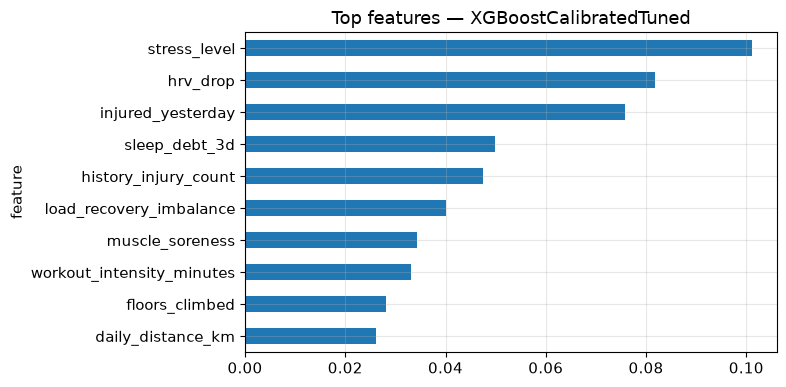

In [38]:
fi = train_result.importance_df
if fi is not None:
    display(fi.head(10))
    fi.head(10).sort_values("importance").plot(kind="barh", x="feature", y="importance", figsize=(8, 4), legend=False, title=f"Top features — {WINNER}")
    plt.tight_layout()
    plt.show()


## Part 6 — Calibration (winner on holdout)


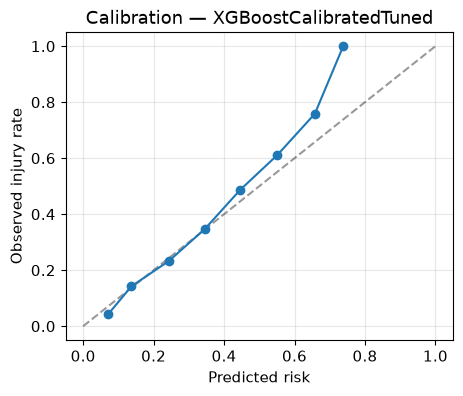

,bin,samples,injury_rate
0,green_0_20,948,0.074895
1,yellow_20_50,192,0.312500
2,red_50_100,60,0.766667


In [39]:
cal = train_result.calibration_bins.get(WINNER)
if cal is not None:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.plot(cal["mean_predicted_risk"], cal["fraction_positive"], "o-")
    ax.set_xlabel("Predicted risk")
    ax.set_ylabel("Observed injury rate")
    ax.set_title(f"Calibration — {WINNER}")
    plt.show()
display(train_result.risk_bins_df)


## Summary


In [40]:
display(pd.DataFrame([
    ("Demo data", f"{SUBSET_ATHLETES} athletes × {SUBSET_DAYS} days"),
    ("Models trained", len(train_result.results_df)),
    ("Pass all gates @ fixed 0.18", f"{int(fixed_gates['pass_all_gates'].sum())} / {len(fixed_gates)}"),
    ("Winner (algorithm)", WINNER),
    ("Operating threshold", f"{OPERATING_THRESHOLD:.2f}"),
    ("Winner tier", int(operating_table.loc[operating_table['Selected'], 'Tier'].iloc[0])),
], columns=["Item", "Value"]))

display(Markdown(
    "_Demo numbers differ from full production run. Algorithm and gates are identical to `run_pipeline.py`._"
))


,Item,Value
0,Demo data,50 athletes × 120 days
1,Models trained,5
2,Pass all gates @ fixed 0.18,1 / 5
3,Winner (algorithm),XGBoostCalibratedTuned
4,Operating threshold,0.12
5,Winner tier,0


_Demo numbers differ from full production run. Algorithm and gates are identical to `run_pipeline.py`._